# RNA Velocity Train/Test MANFIT Prediction

Run the MANFIT train/test prediction workflow on cell cycle and pancreas data. Cell cycle is fit in the original feature space, while pancreas enables the fitter's global PCA reduction before manifold fitting.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "method_tests":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.train_test_evaluation import fit_train_test_manifold_predictions

In [2]:
BASE_FITTER_KWARGS = {
    "k": 25,
    "T": 5,
    "PCA_dim": 30,
    "d_mode": "adaptive",
    "adaptive_variance_threshold": 0.8,
    "adaptive_d_min": 2,
}

DATASETS = {
    "cell_cycle": {
        "label": "Cell cycle",
        "X": PROJECT_ROOT / "data/cell_cycle/X_cc.npy",
        "V": PROJECT_ROOT / "data/cell_cycle/V_cc.npy",
        "color": PROJECT_ROOT / "data/cell_cycle/color_cell_cycle_relativePos.npy",
        "stratify": False,
        "fitter_kwargs": {**BASE_FITTER_KWARGS, "use_PCA": False},
    },
    "pancreas": {
        "label": "Pancreas",
        "X": PROJECT_ROOT / "data/pancreas/X_pca.npy",
        "V": PROJECT_ROOT / "data/pancreas/V_pca_stochastic.npy",
        "color": PROJECT_ROOT / "data/pancreas/color_clusters.npy",
        "stratify": True,
        "fitter_kwargs": {**BASE_FITTER_KWARGS, "use_PCA": True},
    },
}

TEST_SIZE = 0.2
RANDOM_STATE = 7
MAX_CELLS_PER_DATASET = None  # Set to an int for faster iteration.
ORANGE = "#CC6F47"

EVAL_KWARGS = {
    "lle_neighbors": 10,
    "velocity_neighbors": 10,
}

MAX_ARROWS = 220


In [3]:
def load_dataset(name):
    spec = DATASETS[name]
    X = np.asarray(np.load(spec["X"], allow_pickle=True), dtype=float)
    V = np.asarray(np.load(spec["V"], allow_pickle=True), dtype=float)
    color = np.load(spec["color"], allow_pickle=True)
    if MAX_CELLS_PER_DATASET is not None and X.shape[0] > MAX_CELLS_PER_DATASET:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = np.sort(rng.choice(X.shape[0], size=MAX_CELLS_PER_DATASET, replace=False))
        X, V, color = X[idx], V[idx], color[idx]
    return X, V, color


def stratify_labels(name, color):
    if not DATASETS[name]["stratify"]:
        return None
    labels, counts = np.unique(color, return_counts=True)
    if labels.size > 1 and np.min(counts) >= 2:
        return color
    return None


def display_values(values):
    values = np.asarray(values)
    if np.issubdtype(values.dtype, np.number):
        return values.astype(float), None
    labels, encoded = np.unique(values, return_inverse=True)
    return encoded.astype(float), labels


def shared_display_projection(raw_train, raw_test, fit_train, fit_test):
    all_points = np.vstack([raw_train, raw_test, fit_train, fit_test])
    if all_points.shape[1] == 1:
        coords = np.column_stack([all_points[:, 0], np.zeros(all_points.shape[0])])
        return (*np.split(coords, np.cumsum([raw_train.shape[0], raw_test.shape[0], fit_train.shape[0]])), None)

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(all_points)
    raw_train_2d, raw_test_2d, fit_train_2d, fit_test_2d = np.split(
        coords,
        np.cumsum([raw_train.shape[0], raw_test.shape[0], fit_train.shape[0]]),
    )
    return raw_train_2d, raw_test_2d, fit_train_2d, fit_test_2d, pca


def project_display_vectors(vectors, display_pca):
    vectors = np.asarray(vectors, dtype=float)
    if display_pca is None:
        if vectors.shape[1] == 1:
            return np.column_stack([vectors[:, 0], np.zeros(vectors.shape[0])])
        return vectors[:, :2]
    return vectors @ display_pca.components_.T


def choose_arrows(n, max_arrows=MAX_ARROWS, seed=RANDOM_STATE):
    if n <= max_arrows:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n, size=max_arrows, replace=False))

In [4]:
def run_train_test_prediction(name):
    X, V, color = load_dataset(name)
    spec = DATASETS[name]
    result = fit_train_test_manifold_predictions(
        X,
        V,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_labels(name, color),
        fitter_kwargs=spec["fitter_kwargs"],
        fit_kwargs={"return_dict": True},
        **EVAL_KWARGS,
    )
    result["name"] = name
    result["label"] = spec["label"]
    result["X"] = X
    result["V"] = V
    result["color"] = color
    return result


results = {name: run_train_test_prediction(name) for name in DATASETS}
{
    name: {
        "n_train": out["train_indices"].size,
        "n_test": out["test_indices"].size,
        "prediction_shape": out["X_test_hat"].shape,
        "use_PCA": out["fitter"].use_PCA,
    }
    for name, out in results.items()
}


{'cell_cycle': {'n_train': 2234,
  'n_test': 559,
  'prediction_shape': (559, 33),
  'use_PCA': False},
 'pancreas': {'n_train': 2956,
  'n_test': 740,
  'prediction_shape': (740, 30),
  'use_PCA': True}}

In [5]:
def plot_vector_field_panel(xy, vectors, colors, title, vector_color, cmap, ax=None, seed=RANDOM_STATE):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.6, 5.8))
    ax.scatter(xy[:, 0], xy[:, 1], c=colors, cmap=cmap, s=13, alpha=0.78, linewidths=0)
    arrow_idx = choose_arrows(xy.shape[0], seed=seed)
    ax.quiver(
        xy[arrow_idx, 0],
        xy[arrow_idx, 1],
        vectors[arrow_idx, 0],
        vectors[arrow_idx, 1],
        color=vector_color,
        alpha=0.72,
        angles="xy",
        scale_units="xy",
        scale=None,
        width=0.0024,
    )
    ax.set_title(title)
    ax.set_xlabel("display PC 1")
    ax.set_ylabel("display PC 2")
    ax.set_aspect("equal", adjustable="box")
    return ax


def plot_train_test_comparison(out):
    X = out["X"]
    V = out["V"]
    color = out["color"]
    train_idx = out["train_indices"]
    test_idx = out["test_indices"]
    fit_result = out["fit_result"]
    fitter = out["fitter"]

    if fitter.global_pca is None:
        X_test_model = X[test_idx]
        V_test_model = V[test_idx]
    else:
        X_test_model = fitter.global_pca.transform(X[test_idx])
        V_test_model = V[test_idx] @ fitter.global_pca.components_.T

    _, _, fit_train_2d, fit_test_2d, display_pca = shared_display_projection(
        fitter.Y,
        X_test_model,
        fit_result["X"],
        out["X_test_hat"],
    )
    fit_v_train_2d = project_display_vectors(fit_result["V"], display_pca)
    fit_v_test_2d = project_display_vectors(out["V_test_hat"], display_pca)

    c_train, label_names = display_values(color[train_idx])
    c_test, _ = display_values(color[test_idx])
    cmap = "viridis" if label_names is None else "tab20"

    combined_xy = np.vstack([fit_train_2d, fit_test_2d])
    mins = combined_xy.min(axis=0)
    maxs = combined_xy.max(axis=0)
    pad = 0.06 * np.maximum(maxs - mins, 1e-9)
    xlim = (mins[0] - pad[0], maxs[0] + pad[0])
    ylim = (mins[1] - pad[1], maxs[1] + pad[1])

    fig_train, ax_train = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
    plot_vector_field_panel(
        fit_train_2d,
        fit_v_train_2d,
        c_train,
        f"{out['label']}: training fitted manifold",
        vector_color=ORANGE,
        cmap=cmap,
        ax=ax_train,
        seed=RANDOM_STATE,
    )
    ax_train.set_xlim(xlim)
    ax_train.set_ylim(ylim)

    fig_test, ax_test = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
    plot_vector_field_panel(
        fit_test_2d,
        fit_v_test_2d,
        c_test,
        f"{out['label']}: held-out predicted manifold",
        vector_color=ORANGE,
        cmap=cmap,
        ax=ax_test,
        seed=RANDOM_STATE + 1,
    )
    ax_test.set_xlim(xlim)
    ax_test.set_ylim(ylim)

    return fig_train, fig_test


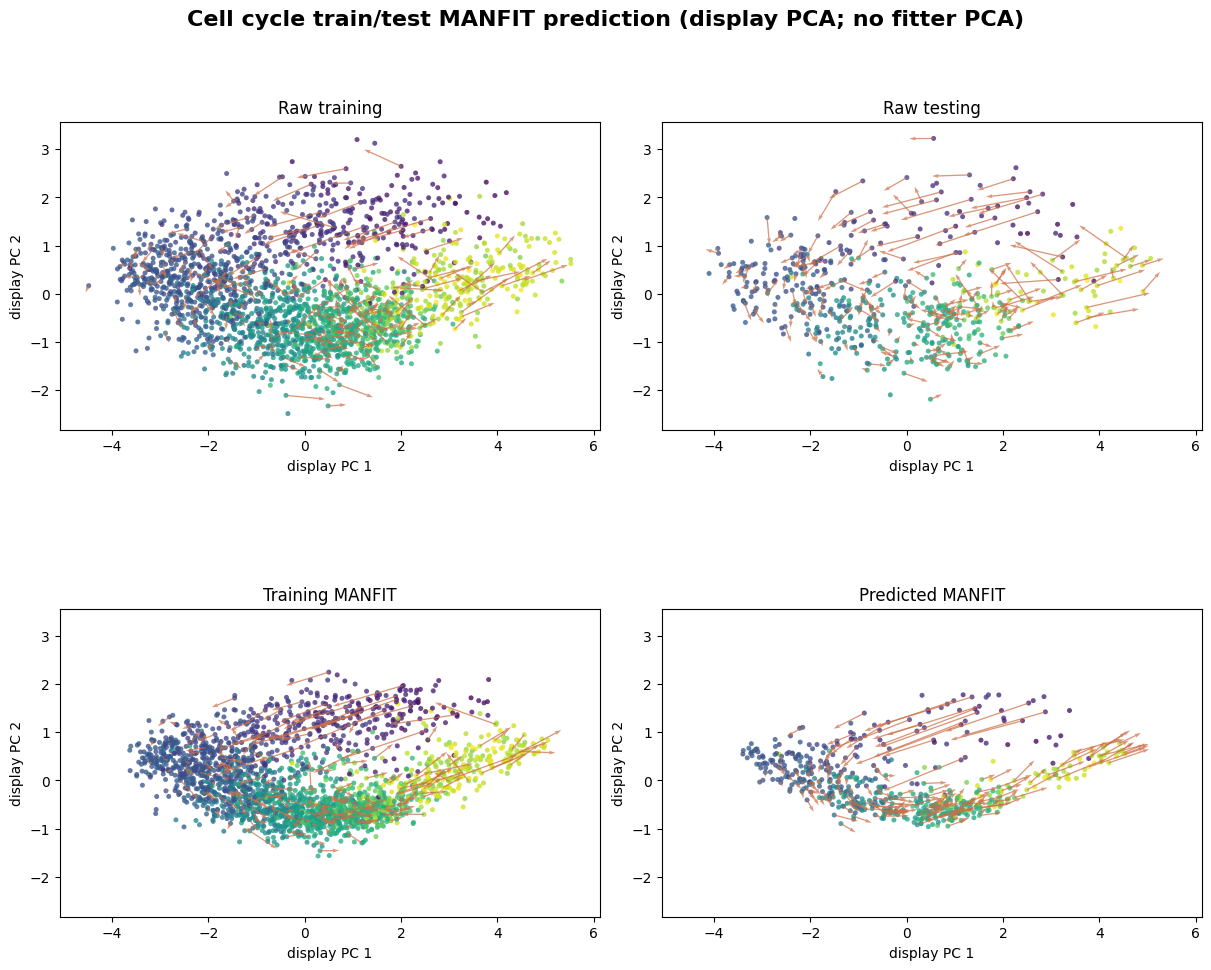

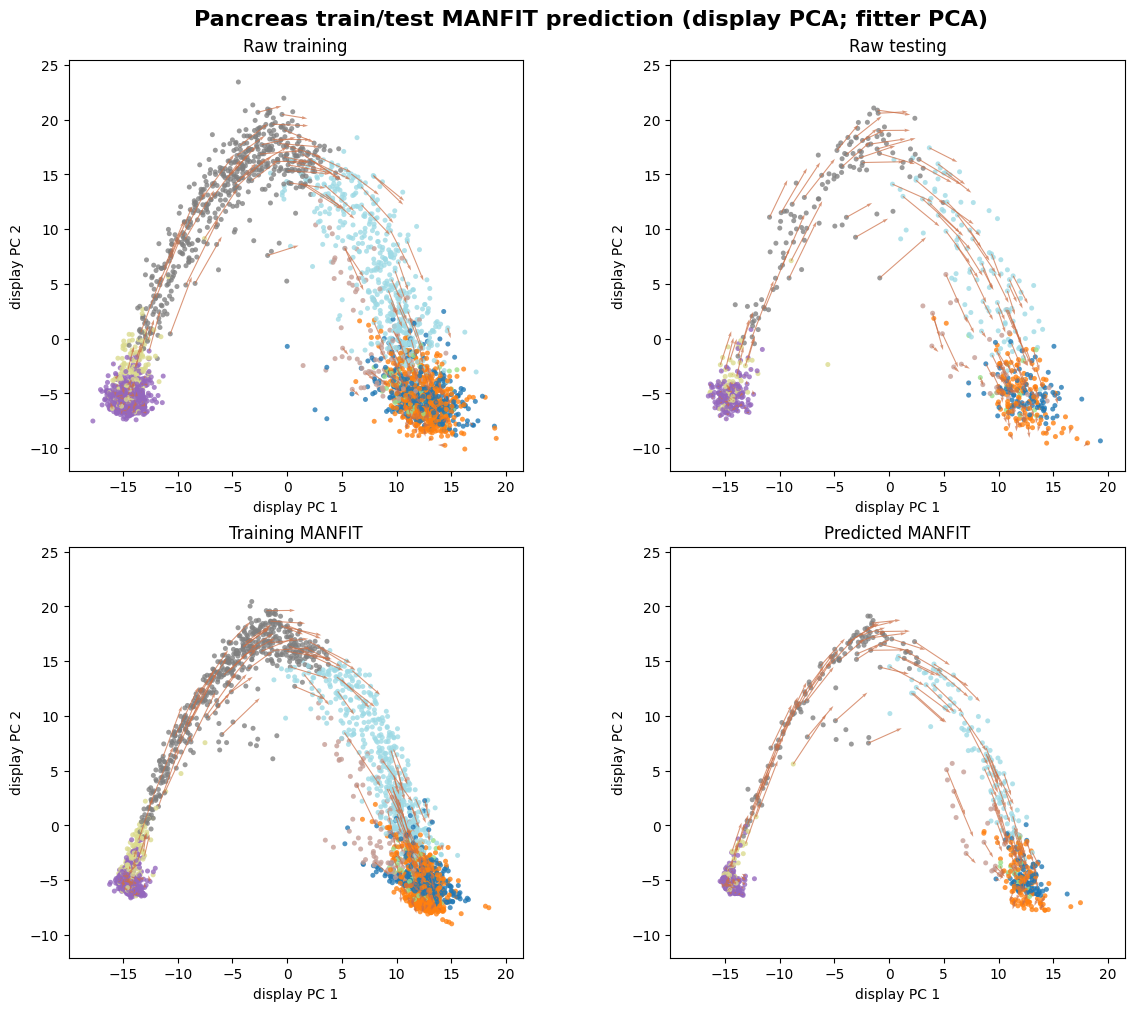

In [6]:
def plot_train_test_2x2(out):
    X = out["X"]
    V = out["V"]
    color = out["color"]
    train_idx = out["train_indices"]
    test_idx = out["test_indices"]
    fit_result = out["fit_result"]
    fitter = out["fitter"]

    if fitter.global_pca is None:
        X_test_model = X[test_idx]
        V_test_model = V[test_idx]
    else:
        X_test_model = fitter.global_pca.transform(X[test_idx])
        V_test_model = V[test_idx] @ fitter.global_pca.components_.T

    raw_train_2d, raw_test_2d, fit_train_2d, fit_test_2d, display_pca = shared_display_projection(
        fitter.Y,
        X_test_model,
        fit_result["X"],
        out["X_test_hat"],
    )
    panels = [
        ("Raw training", raw_train_2d, project_display_vectors(fitter.W, display_pca), color[train_idx], ORANGE, RANDOM_STATE),
        ("Raw testing", raw_test_2d, project_display_vectors(V_test_model, display_pca), color[test_idx], ORANGE, RANDOM_STATE + 1),
        ("Training MANFIT", fit_train_2d, project_display_vectors(fit_result["V"], display_pca), color[train_idx], ORANGE, RANDOM_STATE + 2),
        ("Predicted MANFIT", fit_test_2d, project_display_vectors(out["V_test_hat"], display_pca), color[test_idx], ORANGE, RANDOM_STATE + 3),
    ]

    all_xy = np.vstack([panel[1] for panel in panels])
    mins = all_xy.min(axis=0)
    maxs = all_xy.max(axis=0)
    pad = 0.06 * np.maximum(maxs - mins, 1e-9)
    xlim = (mins[0] - pad[0], maxs[0] + pad[0])
    ylim = (mins[1] - pad[1], maxs[1] + pad[1])

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    for ax, (title, xy, vec, panel_color, arrow_color, seed) in zip(axes.flat, panels):
        c_values, label_names = display_values(panel_color)
        cmap = "viridis" if label_names is None else "tab20"
        plot_vector_field_panel(
            xy,
            vec,
            c_values,
            title,
            vector_color=arrow_color,
            cmap=cmap,
            ax=ax,
            seed=seed,
        )
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

    pca_note = "fitter PCA" if out["fitter"].use_PCA else "no fitter PCA"
    fig.suptitle(f"{out['label']} train/test MANFIT prediction (display PCA; {pca_note})", fontsize=16, fontweight="bold")
    return fig


for out in results.values():
    plot_train_test_2x2(out)
    plt.show()


In [7]:
def residual_moments(residual):
    residual = np.asarray(residual, dtype=float)
    bias = residual.mean(axis=0)
    centered = residual - bias
    return {
        "bias_norm": float(np.linalg.norm(bias)),
        "mean_component_bias": float(np.mean(bias)),
        "mean_abs_component_bias": float(np.mean(np.abs(bias))),
        "total_variance": float(np.mean(np.sum(centered**2, axis=1))),
        "mean_component_variance": float(np.mean(np.var(residual, axis=0))),
        "rms_residual": float(np.sqrt(np.mean(np.sum(residual**2, axis=1)))),
    }


def manifold_residuals(out):
    X = out["X"]
    V = out["V"]
    test_idx = out["test_indices"]
    fit_result = out["fit_result"]
    fitter = out["fitter"]

    if fitter.global_pca is None:
        X_test_model = X[test_idx]
        V_test_model = V[test_idx]
    else:
        X_test_model = fitter.global_pca.transform(X[test_idx])
        V_test_model = V[test_idx] @ fitter.global_pca.components_.T

    return {
        ("train", "position"): fit_result["X"] - fitter.Y,
        ("test", "position"): out["X_test_hat"] - X_test_model,
        ("train", "velocity"): fit_result["V"] - fitter.W,
        ("test", "velocity"): out["V_test_hat"] - V_test_model,
    }


def residual_summary(out):
    rows = []
    for (split, quantity), residual in manifold_residuals(out).items():
        rows.append({
            "dataset": out["label"],
            "split": split,
            "quantity": quantity,
            "n": residual.shape[0],
            "dim": residual.shape[1],
            **residual_moments(residual),
        })
    return pd.DataFrame(rows)


def residual_long_frame(out):
    rows = []
    for (split, quantity), residual in manifold_residuals(out).items():
        residual_norm = np.linalg.norm(residual, axis=1)
        rows.extend(
            {
                "dataset": out["label"],
                "split": split,
                "quantity": quantity,
                "residual_norm": float(value),
            }
            for value in residual_norm
        )
    return pd.DataFrame(rows)


residual_summaries = pd.concat(
    [residual_summary(out) for out in results.values()],
    ignore_index=True,
)
residual_summaries


,dataset,split,quantity,n,dim,bias_norm,mean_component_bias,mean_abs_component_bias,total_variance,mean_component_variance,rms_residual
0,Cell cycle,train,position,2234,33,0.071970,0.001448,0.009486,3.616605,0.109594,1.903099
1,Cell cycle,test,position,559,33,0.141018,0.001398,0.020731,5.850188,0.177278,2.422824
2,Cell cycle,train,velocity,2234,33,1.102856,-0.001306,0.161158,19.694856,0.596814,4.572871
3,Cell cycle,test,velocity,559,33,1.082346,0.023520,0.163987,28.467503,0.862652,5.444169
4,Pancreas,train,position,2956,30,0.257533,0.004280,0.032791,19.699572,0.656652,4.445885
5,Pancreas,test,position,740,30,0.306066,0.013132,0.045225,29.886495,0.996216,5.475415
6,Pancreas,train,velocity,2956,30,0.017393,-0.000755,0.002265,0.012532,0.000418,0.113290
7,Pancreas,test,velocity,740,30,0.017599,-0.000462,0.002256,0.020028,0.000668,0.142612


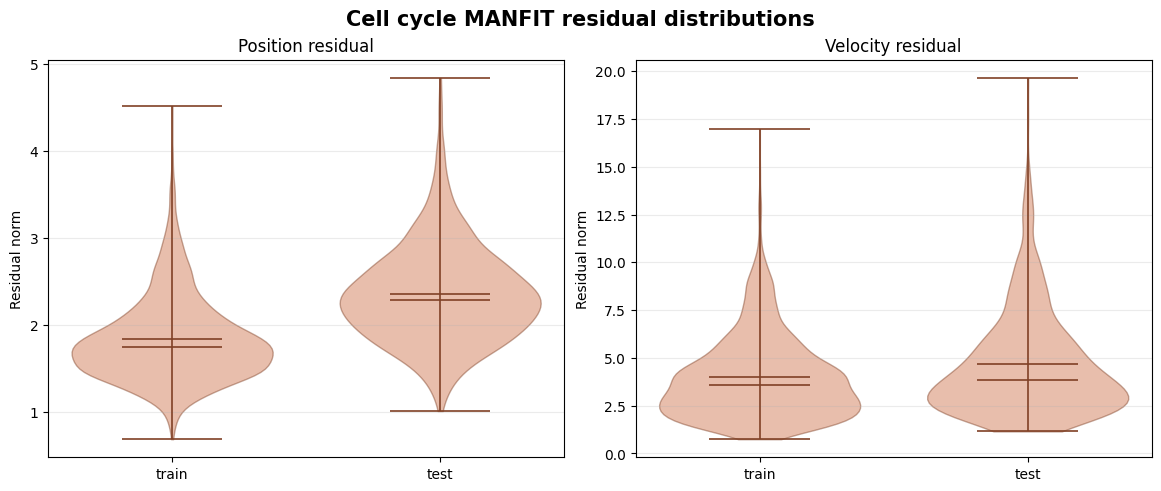

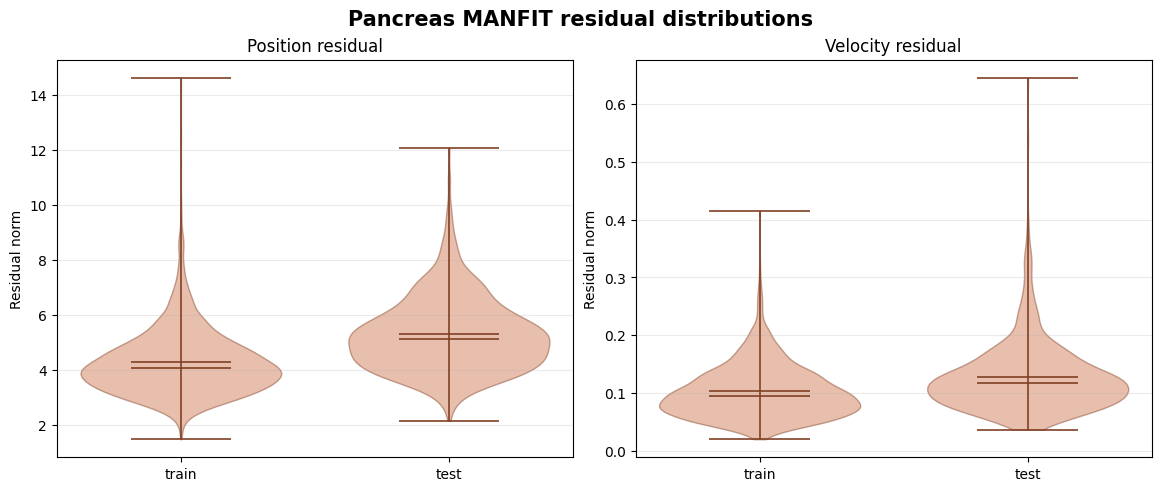

In [8]:
def plot_residual_violins(out):
    residual_long = residual_long_frame(out)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
    for ax, quantity in zip(axes, ["position", "velocity"]):
        subset = residual_long[residual_long["quantity"] == quantity]
        data = [subset[subset["split"] == split]["residual_norm"].to_numpy() for split in ["train", "test"]]
        parts = ax.violinplot(data, showmeans=True, showmedians=True, widths=0.75)
        for body in parts["bodies"]:
            body.set_facecolor(ORANGE)
            body.set_edgecolor("#804126")
            body.set_alpha(0.45)
        for key in ["cmeans", "cmedians", "cbars", "cmins", "cmaxes"]:
            parts[key].set_color("#804126")
            parts[key].set_linewidth(1.2)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["train", "test"])
        ax.set_ylabel("Residual norm")
        ax.set_title(f"{quantity.capitalize()} residual")
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle(f"{out['label']} MANFIT residual distributions", fontsize=15, fontweight="bold")
    return fig


for out in results.values():
    plot_residual_violins(out)
    plt.show()


In [9]:
def cosine_rows(a, b, eps=1e-12):
    denom = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + eps
    return np.sum(a * b, axis=1) / denom


def local_neighbor_cosine(points, vectors, n_neighbors=25):
    points = np.asarray(points, dtype=float)
    vectors = np.asarray(vectors, dtype=float)
    n_neighbors = min(int(n_neighbors), points.shape[0] - 1)
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(points)
    indices = nbrs.kneighbors(points, return_distance=False)[:, 1:]
    per_point = np.zeros(points.shape[0], dtype=float)
    for i, neigh in enumerate(indices):
        vi = np.repeat(vectors[i][None, :], neigh.shape[0], axis=0)
        per_point[i] = float(np.mean(cosine_rows(vi, vectors[neigh])))
    return per_point, indices


def local_consistency_summary(out, n_neighbors=25):
    fit_result = out["fit_result"]
    configs = {
        "train": (fit_result["X"], fit_result["V"]),
        "test": (out["X_test_hat"], out["V_test_hat"]),
    }
    rows = []
    per_point = []
    for split, (points, vectors) in configs.items():
        cosines, _ = local_neighbor_cosine(points, vectors, n_neighbors=n_neighbors)
        rows.append({
            "dataset": out["label"],
            "split": split,
            "n": points.shape[0],
            "neighbor_count": min(n_neighbors, points.shape[0] - 1),
            "mean_neighbor_cosine": float(np.mean(cosines)),
            "median_neighbor_cosine": float(np.median(cosines)),
            "std_neighbor_cosine": float(np.std(cosines)),
            "fraction_positive_neighbor_cosine": float(np.mean(cosines > 0.0)),
        })
        per_point.extend({"split": split, "neighbor_cosine": float(value)} for value in cosines)
    return pd.DataFrame(rows), pd.DataFrame(per_point)


local_consistency_tables = []
local_consistency_point_tables = []
for name, out in results.items():
    summary, points = local_consistency_summary(out, n_neighbors=out["fitter"].k)
    points.insert(0, "dataset", out["label"])
    local_consistency_tables.append(summary)
    local_consistency_point_tables.append(points)

local_consistency = pd.concat(local_consistency_tables, ignore_index=True)
local_consistency_points = pd.concat(local_consistency_point_tables, ignore_index=True)
local_consistency


,dataset,split,n,neighbor_count,mean_neighbor_cosine,median_neighbor_cosine,std_neighbor_cosine,fraction_positive_neighbor_cosine
0,Cell cycle,train,2234,25,0.231902,0.230762,0.238660,0.846016
1,Cell cycle,test,559,25,0.640246,0.683830,0.201984,0.983900
2,Pancreas,train,2956,25,0.741754,0.840947,0.246389,0.982409
3,Pancreas,test,740,25,0.803156,0.866703,0.211966,0.987838


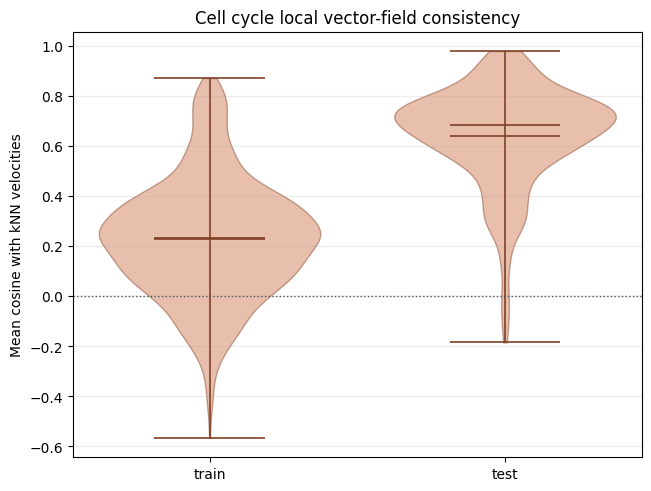

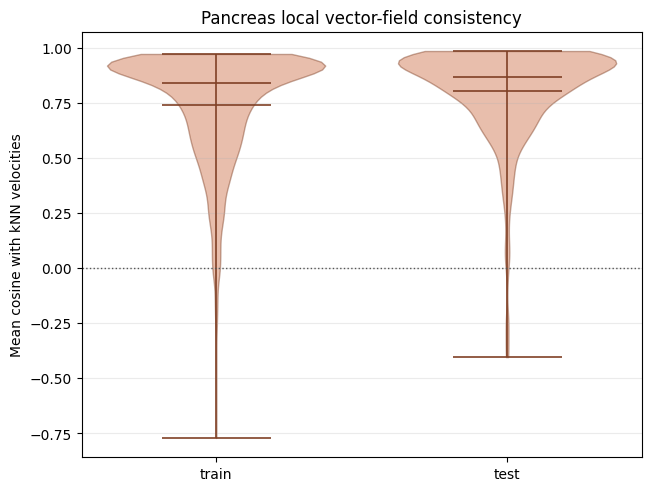

In [10]:
def plot_local_consistency_violin(out, local_consistency_points):
    dataset_points = local_consistency_points[local_consistency_points["dataset"] == out["label"]]
    fig, ax = plt.subplots(figsize=(6.4, 4.8), constrained_layout=True)
    data = [
        dataset_points[dataset_points["split"] == split]["neighbor_cosine"].to_numpy()
        for split in ["train", "test"]
    ]
    parts = ax.violinplot(data, showmeans=True, showmedians=True, widths=0.75)
    for body in parts["bodies"]:
        body.set_facecolor(ORANGE)
        body.set_edgecolor("#804126")
        body.set_alpha(0.45)
    for key in ["cmeans", "cmedians", "cbars", "cmins", "cmaxes"]:
        parts[key].set_color("#804126")
        parts[key].set_linewidth(1.2)
    ax.axhline(0.0, color="#555555", linestyle=":", linewidth=1)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["train", "test"])
    ax.set_ylabel("Mean cosine with kNN velocities")
    ax.set_title(f"{out['label']} local vector-field consistency")
    ax.grid(axis="y", alpha=0.25)
    return fig


for out in results.values():
    plot_local_consistency_violin(out, local_consistency_points)
    plt.show()
